#MarketPlace Delivery Performance
Objective:
For orders delivered in May 2026, what is the on-time delivery rate by courier?

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

In [110]:
df= pd.read_csv("task1_marketplace_delivery_sla_raw(in).csv")

In [111]:
df.head()

,order_id,customer_id,order_date,shipped_at,delivered_at,updated_at,city,courier,payment_status,order_status,promised_days,order_value,is_test_order
0,O1001,C01,29-04-26,1/5/2026,3/5/2026,3/5/2026,Bengaluru,ShipQuick,Paid,Delivered,2,1200,No
1,O1002,C02,2/5/2026,3/5/2026,7/5/2026,7/5/2026,Mumbai,shipquick,pending,delivered,3,900,No
2,O1002,C02,2/5/2026,3/5/2026,7/5/2026,8/5/2026,Mumbai,ShipQuick,Paid,Delivered,3,900,No
3,O1003,C03,4/5/2026,5/5/2026,6/5/2026,6/5/2026,Delhi,FastBee,Pending,Delivered,2,650,No
4,O1004,C04,5/5/2026,6/5/2026,1/6/2026,1/6/2026,Pune,Blue Dart,Paid,Delivered,4,2000,No


##Data understanding


In [112]:
df.shape

(10, 13)

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        10 non-null     object
 1   customer_id     10 non-null     object
 2   order_date      10 non-null     object
 3   shipped_at      10 non-null     object
 4   delivered_at    9 non-null      object
 5   updated_at      10 non-null     object
 6   city            10 non-null     object
 7   courier         10 non-null     object
 8   payment_status  10 non-null     object
 9   order_status    10 non-null     object
 10  promised_days   10 non-null     int64 
 11  order_value     10 non-null     int64 
 12  is_test_order   10 non-null     object
dtypes: int64(2), object(11)
memory usage: 1.1+ KB


In [114]:
df.columns

Index(['order_id', 'customer_id', 'order_date', 'shipped_at', 'delivered_at',
       'updated_at', 'city', 'courier', 'payment_status', 'order_status',
       'promised_days', 'order_value', 'is_test_order'],
      dtype='object')

##Date cleaning

In [115]:
date_column=["order_date","shipped_at", "delivered_at", "updated_at"]
for col in date_column:
  df[col]=pd.to_datetime(df[col],dayfirst=True, format="mixed", errors="coerce")
df[date_column].head()

,order_date,shipped_at,delivered_at,updated_at
0,2026-04-29,2026-05-01,2026-05-03,2026-05-03
1,2026-05-02,2026-05-03,2026-05-07,2026-05-07
2,2026-05-02,2026-05-03,2026-05-07,2026-05-08
3,2026-05-04,2026-05-05,2026-05-06,2026-05-06
4,2026-05-05,2026-05-06,2026-06-01,2026-06-01


In [116]:
df["courier"].unique()

array(['ShipQuick', 'shipquick', 'FastBee', 'Blue Dart', 'Fastbee',
       'Bluedart'], dtype=object)

In [117]:
df["courier"]=(df["courier"].str.strip().str.lower().str.replace(" ",""))
df["courier"].unique()

array(['shipquick', 'fastbee', 'bluedart'], dtype=object)

In [118]:
df["order_status"]=(df["order_status"].str.strip().str.lower())
df["order_status"].unique()

array(['delivered', 'cancelled'], dtype=object)

In [119]:
df["is_test_order"]=(df["is_test_order"].str.strip().str.lower().eq("yes"))
df["is_test_order"]

,is_test_order
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,True
9,False


In [120]:
df= df.sort_values("updated_at")

In [121]:
df["order_id"].duplicated().sum()

np.int64(2)

In [122]:
df=df.drop_duplicates(subset="order_id", keep="last")

In [123]:
df["order_id"].duplicated().sum()

np.int64(0)

#may_orders

In [124]:
may_orders= df[(df["delivered_at"]>= pd.Timestamp("2026-05-01")) & (df["delivered_at"]< pd.Timestamp("2026-06-01"))].copy()

In [125]:
may_orders

,order_id,customer_id,order_date,shipped_at,delivered_at,updated_at,city,courier,payment_status,order_status,promised_days,order_value,is_test_order
0,O1001,C01,2026-04-29,2026-05-01,2026-05-03,2026-05-03,Bengaluru,shipquick,Paid,delivered,2,1200,False
3,O1003,C03,2026-05-04,2026-05-05,2026-05-06,2026-05-06,Delhi,fastbee,Pending,delivered,2,650,False
2,O1002,C02,2026-05-02,2026-05-03,2026-05-07,2026-05-08,Mumbai,shipquick,Paid,delivered,3,900,False
7,O1006,C06,2026-05-10,2026-05-11,2026-05-14,2026-05-14,Mumbai,bluedart,Paid,delivered,3,1500,False
8,O1007,C07,2026-05-12,2026-05-13,2026-05-15,2026-05-15,Bangalore,shipquick,Paid,delivered,2,1,True
9,O1008,C08,2026-05-15,2026-05-16,2026-05-18,2026-05-18,Pune,fastbee,Paid,delivered,-2,500,False


##dont want test orders, cancelled orders,missing delivery dates

In [126]:
eligible= may_orders[(~may_orders["is_test_order"]) & (may_orders["order_status"]=="delivered") & (may_orders["delivered_at"].notna()) & (may_orders["shipped_at"].notna()) & (may_orders["promised_days"]>=0)].copy()

In [127]:
eligible

,order_id,customer_id,order_date,shipped_at,delivered_at,updated_at,city,courier,payment_status,order_status,promised_days,order_value,is_test_order
0,O1001,C01,2026-04-29,2026-05-01,2026-05-03,2026-05-03,Bengaluru,shipquick,Paid,delivered,2,1200,False
3,O1003,C03,2026-05-04,2026-05-05,2026-05-06,2026-05-06,Delhi,fastbee,Pending,delivered,2,650,False
2,O1002,C02,2026-05-02,2026-05-03,2026-05-07,2026-05-08,Mumbai,shipquick,Paid,delivered,3,900,False
7,O1006,C06,2026-05-10,2026-05-11,2026-05-14,2026-05-14,Mumbai,bluedart,Paid,delivered,3,1500,False


## delivery performance

In [128]:
eligible["actual_transit_days"] = (eligible["delivered_at"] - eligible["shipped_at"]).dt.days

In [129]:
eligible[["order_id","courier","actual_transit_days", "promised_days"]]

,order_id,courier,actual_transit_days,promised_days
0,O1001,shipquick,2,2
3,O1003,fastbee,1,2
2,O1002,shipquick,4,3
7,O1006,bluedart,3,3


In [130]:
#on time or late

eligible["delivery_status"]=(eligible["actual_transit_days"]<= eligible["promised_days"]).map({True:"ontime", False:"late"})


In [131]:
eligible[
    ["order_id", "courier", "actual_transit_days", "promised_days", "delivery_status"]
]

,order_id,courier,actual_transit_days,promised_days,delivery_status
0,O1001,shipquick,2,2,ontime
3,O1003,fastbee,1,2,ontime
2,O1002,shipquick,4,3,late
7,O1006,bluedart,3,3,ontime


##courier performance

In [132]:
courier_performance = eligible.groupby("courier").agg(
    eligible_orders=("order_id", "nunique"),
    ontime_orders=("delivery_status", lambda x: (x=="ontime").sum())
).reset_index()

In [133]:
courier_performance["on_time_rate"]=(courier_performance['ontime_orders']/courier_performance['eligible_orders']).round(2)

In [134]:
courier_performance

,courier,eligible_orders,ontime_orders,on_time_rate
0,bluedart,1,1,1.0
1,fastbee,1,1,1.0
2,shipquick,2,1,0.5


##visualization

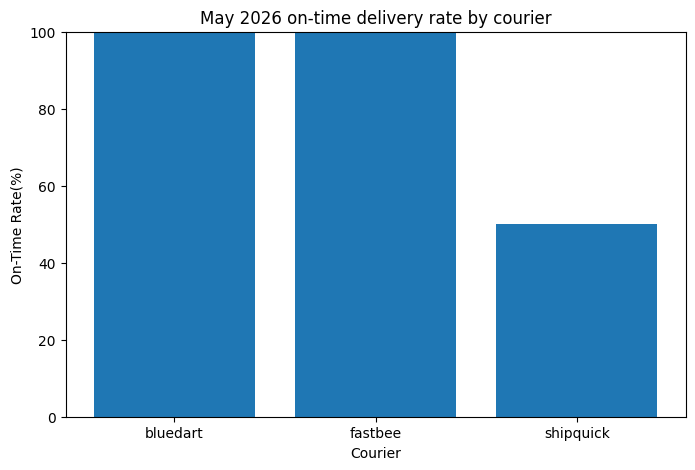

In [145]:
plt.figure(figsize=(8,5))

plt.bar(courier_performance["courier"], courier_performance["on_time_rate"]*100)

plt.xlabel("Courier")
plt.ylabel("On-Time Rate(%)")
plt.title("May 2026 on-time delivery rate by courier")
plt.ylim(0,100)
plt.yticks(range(0,101,20))

plt.show()

###eligible orders vs on-time orders

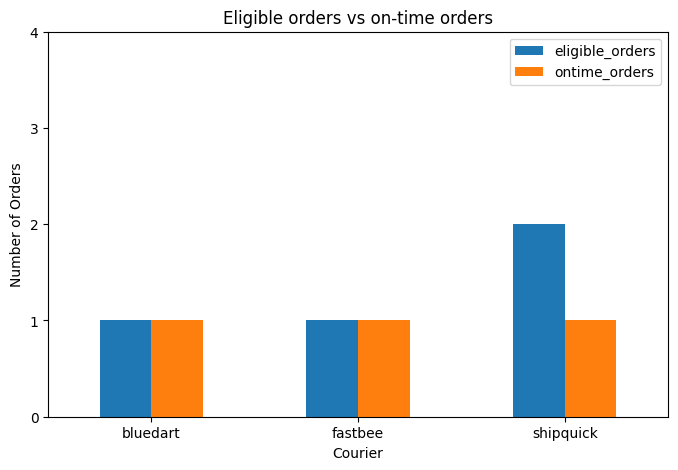

In [139]:
chart_data = courier_performance.set_index("courier")[["eligible_orders", "ontime_orders"]]
chart_data.plot(kind="bar", figsize=(8, 5))

plt.xlabel("Courier")
plt.ylabel("Number of Orders")
plt.title("Eligible orders vs on-time orders")
plt.xticks(rotation=0)
plt.yticks(range(0, eligible["order_id"].nunique()+1))
plt.show()

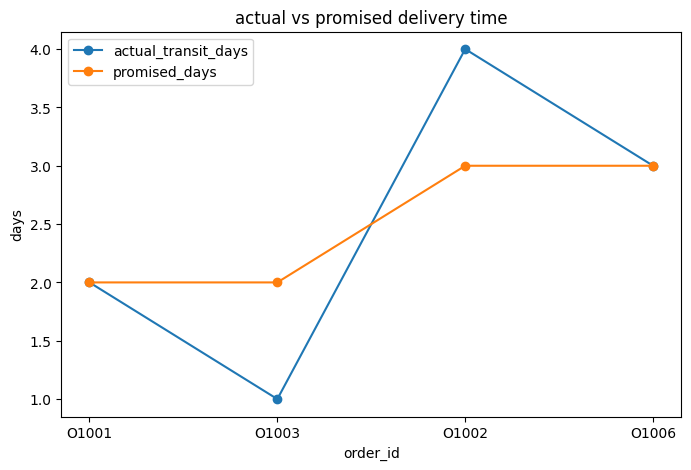

In [137]:
plt.figure(figsize=(8,5))

plt.plot(eligible["order_id"],eligible["actual_transit_days"], marker="o", label="actual_transit_days")
plt.plot(eligible["order_id"],eligible["promised_days"], marker="o", label="promised_days")

plt.xlabel("order_id")
plt.ylabel("days")
plt.title("actual vs promised delivery time")
plt.legend()

plt.show()